# Solar Limb Model Inference

Load a trained limb model and generate disk predictions for sunchart images.

**Configuration:** Set model, input-image, and prediction-output paths before execution.

In [1]:
# Step 1: Import dependencies and initialise this stage.
from tensorflow.keras.models import load_model
model = load_model("/home/dibya/ML_work/solar_limb_segmentation_model.h5",compile=False)

2025-04-03 14:55:18.771631: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-03 14:55:18.779282: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-03 14:55:18.805615: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-03 14:55:18.846214: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-03 14:55:18.857359: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-03 14:55:20.724303: W tensorflow/compiler/tf2tensorrt/utils/p

In [ ]:
# Step 2: Run the next processing stage.
print(model.summary())

In [2]:
# Step 3: Run the next processing stage.
test_directory = '/kodaiData/Drawings/Raw/1953/HR/11/'

In [3]:
# Step 4: Run the next processing stage.
test_dataset=[]

In [4]:
# Step 5: Import dependencies and initialise this stage.
import os
import cv2
import numpy as np
from PIL import Image

tif_files = [os.path.join(root, filename) for root, _, files in os.walk(test_directory) for filename in files if filename.endswith('sch_19531120_0955_kkxt.tif')]
tif_files.sort()


for image_path in tif_files:
            image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)
            image = Image.fromarray(image)
            image = image.resize((256, 256))
            test_dataset.append(np.array(image))

In [5]:
# Step 6: Run the next processing stage.
name_image = []
for root, dirs, files in os.walk(test_directory):
    for image_name in files:
        if image_name.lower().endswith('sch_19531120_0955_kkxt.tif'):
            image_path = os.path.join(root, image_name)
            name_image.append(image_name)
            name_image.sort()
print(name_image)

['sch_19531120_0955_kkxt.tif']


In [6]:
# Step 7: Run the next processing stage.
tests = np.array(test_dataset)

1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 3s 3s/step


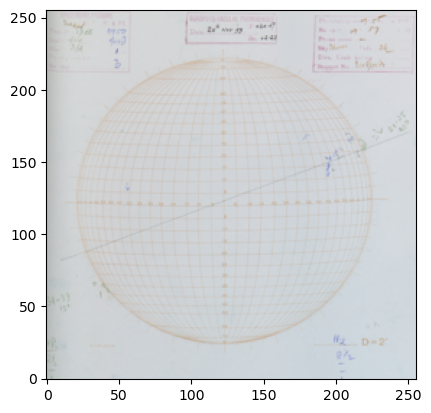

In [ ]:
# Step 8: Import dependencies and initialise this stage.
import matplotlib.pyplot as plt

for i in range(0,len(tests)): 
    
    b,g,r=cv2.split(tests[i])
    img_matplotlib_xtest_=cv2.merge([r,g,b])
    flipped_image = cv2.flip(tests[i], 0)
    prediction_ = model.predict(flipped_image.reshape(1,256,256,3))       
    prediction_ = prediction_.reshape(256,256)
    
    y_train_test = np.reshape(prediction_,(256,256))
    kernel = np.ones((3,3), np.uint8)
    kernel1 = np.ones((2,2), np.uint8)#2,2
    kernel2 = np.ones((1,1), np.uint8)#1,1
    closing = cv2.morphologyEx(y_train_test, cv2.MORPH_CLOSE, kernel, iterations=3)
    erosion = cv2.erode(closing, kernel1, iterations=1)
    bg = cv2.dilate(erosion,kernel2,iterations=4)
    mask = (bg >= 0.2).astype(int)
    mask = mask.clip(max=1)

    
    
    
    plt.imshow(flipped_image,origin='lower',cmap='gray')
    cv2.imwrite("/home/dibya/ML_work/limb_prediction/"+name_image[i]+".png",y_train_test)


plt.show()

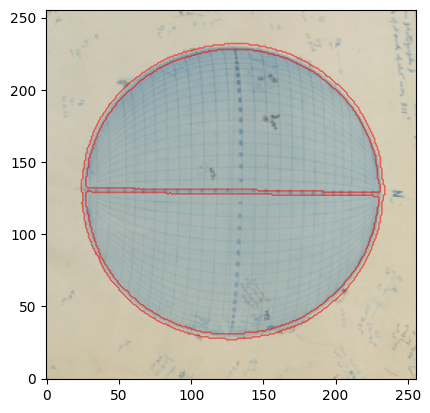

In [ ]:
# Step 9: Generate or inspect model predictions.
image = cv2.imread('/media/ExtHDD1/1909/HR/01/sch_19090107_0807_kxxk.tif',cv2.COLOR_BGR2RGB)
image = Image.fromarray(image)
image= image.resize((256,256))
b,g,r=cv2.split(np.array(image))
img_matplotlib=cv2.merge([r,g,b])
image_test = cv2.flip(img_matplotlib, 0)


image_ = cv2.imread('/home/dibya/limb_prediction1/sch_19090107_0807_kxxk.tif.png',cv2.COLOR_BGR2RGB)
image_ = Image.fromarray(image_)
plt.imshow(image_test,origin='lower')
plt.contour(image_,origin='lower',colors='red',linewidths=0.1)